import libaries needed for code

In [ ]:
import pandas as pd
import os
import json
import seaborn as sns
import numpy as np

extract the json files into a dataframe

In [110]:
# Select the directory where cmc json files are stored
rootdir = ''

# Initialize an empty DataFrame
df_data = pd.DataFrame()

# Iterate through files in the directory
for subdir, dirs, files in os.walk(rootdir):
    for file in files:
        if file.endswith('.json'):
            file_path = os.path.join(subdir, file)
            # Load the JSON file
            with open(file_path, 'r') as f:
                data = json.load(f)

            # Extract data and create a DataFrame for the current JSON file and save each as a row of a dataframe
            cmc_data = pd.json_normalize(data['data'])
            df_temp = pd.DataFrame({
                'Concentration (mM)': cmc_data['x'],
                'Surface Tension (mN/m)': cmc_data['y'],
                'name': data['compound']['name'],
                'SMILES': data['compound']['SMILES'],
                'CMC_value': data['CMC_value']['CMC (mM)'],
                'Surface_Tension_CMC_mN/m': data['CMC_value']['Surface Tension at CMC (mN/m)'],
                'pre_CMC_line': str(data['line_of_best_fit'][0]),
                'post_CMC_line': str(data['line_of_best_fit'][1])
            })

            # Append the DataFrame for the current JSON file to df_data
            df_data = df_data.append(df_temp, ignore_index=True)

# Display the combined DataFrame
df_data.head(35)

,Concentration (mM),Surface Tension (mN/m),name,SMILES,CMC_value,Surface_Tension_CMC_mN/m,pre_CMC_line,post_CMC_line
0,95.02,32.20,compound 15,[O-]S(=O)(=O)CNC(=S)NC1=CC=C(C=C1)C(F)(F)F.C1=...,28.95,30.25,"{'slope': -0.3178, 'y_intercept': 39.455, 'R_s...","{'slope': 0.0231, 'y_intercept': 29.587, 'R_sq..."
1,90.04,31.46,compound 15,[O-]S(=O)(=O)CNC(=S)NC1=CC=C(C=C1)C(F)(F)F.C1=...,28.95,30.25,"{'slope': -0.3178, 'y_intercept': 39.455, 'R_s...","{'slope': 0.0231, 'y_intercept': 29.587, 'R_sq..."
2,79.94,31.29,compound 15,[O-]S(=O)(=O)CNC(=S)NC1=CC=C(C=C1)C(F)(F)F.C1=...,28.95,30.25,"{'slope': -0.3178, 'y_intercept': 39.455, 'R_s...","{'slope': 0.0231, 'y_intercept': 29.587, 'R_sq..."
3,69.99,31.29,compound 15,[O-]S(=O)(=O)CNC(=S)NC1=CC=C(C=C1)C(F)(F)F.C1=...,28.95,30.25,"{'slope': -0.3178, 'y_intercept': 39.455, 'R_s...","{'slope': 0.0231, 'y_intercept': 29.587, 'R_sq..."
4,60.03,30.47,compound 15,[O-]S(=O)(=O)CNC(=S)NC1=CC=C(C=C1)C(F)(F)F.C1=...,28.95,30.25,"{'slope': -0.3178, 'y_intercept': 39.455, 'R_s...","{'slope': 0.0231, 'y_intercept': 29.587, 'R_sq..."
5,49.93,30.75,compound 15,[O-]S(=O)(=O)CNC(=S)NC1=CC=C(C=C1)C(F)(F)F.C1=...,28.95,30.25,"{'slope': -0.3178, 'y_intercept': 39.455, 'R_s...","{'slope': 0.0231, 'y_intercept': 29.587, 'R_sq..."
6,40.11,30.64,compound 15,[O-]S(=O)(=O)CNC(=S)NC1=CC=C(C=C1)C(F)(F)F.C1=...,28.95,30.25,"{'slope': -0.3178, 'y_intercept': 39.455, 'R_s...","{'slope': 0.0231, 'y_intercept': 29.587, 'R_sq..."
7,29.88,30.41,compound 15,[O-]S(=O)(=O)CNC(=S)NC1=CC=C(C=C1)C(F)(F)F.C1=...,28.95,30.25,"{'slope': -0.3178, 'y_intercept': 39.455, 'R_s...","{'slope': 0.0231, 'y_intercept': 29.587, 'R_sq..."
8,24.90,31.97,compound 15,[O-]S(=O)(=O)CNC(=S)NC1=CC=C(C=C1)C(F)(F)F.C1=...,28.95,30.25,"{'slope': -0.3178, 'y_intercept': 39.455, 'R_s...","{'slope': 0.0231, 'y_intercept': 29.587, 'R_sq..."
9,22.54,32.27,compound 15,[O-]S(=O)(=O)CNC(=S)NC1=CC=C(C=C1)C(F)(F)F.C1=...,28.95,30.25,"{'slope': -0.3178, 'y_intercept': 39.455, 'R_s...","{'slope': 0.0231, 'y_intercept': 29.587, 'R_sq..."


use these dataframees to replot the graphs from the ESI - https://doi.org/10.1002/cmdc.202000533

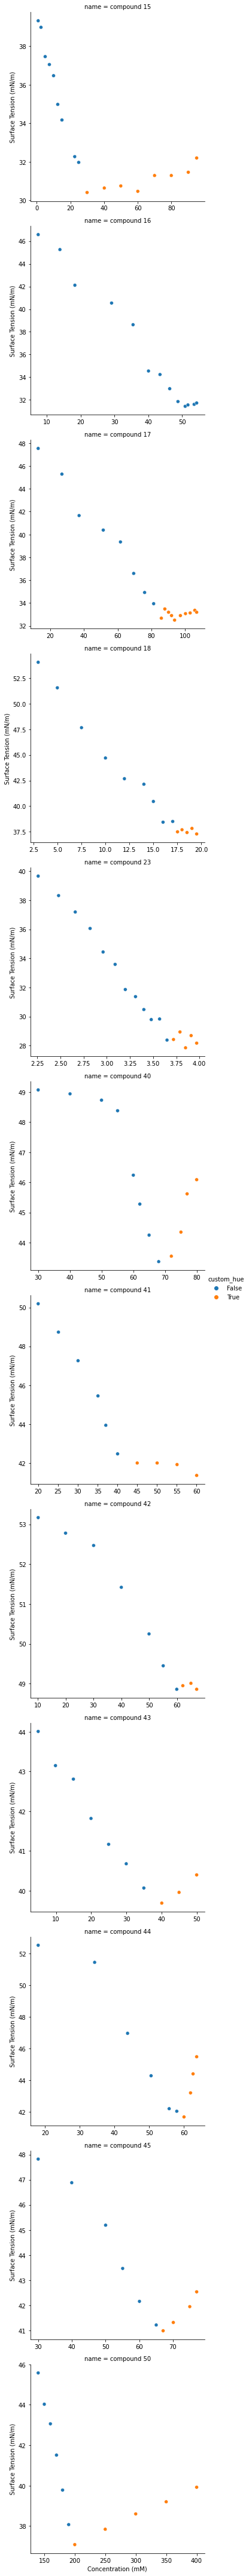

In [108]:
# Define a custom hue based on whether the concentration is greater than or equal to CMC_value
df_data['custom_hue'] = df_data['Concentration (mM)'] >= df_data['CMC_value'].astype(float)

sns.relplot(data=df_data,x='Concentration (mM)',y='Surface Tension (mN/m)', kind='scatter',row='name',facet_kws={'sharex': False, 'sharey': False},hue='custom_hue')